# 1. Understanding the problem space

All files from the “sampled-datasets” folder have been downloaded here using *sync* from the AWS bucket. All this information has been downloaded via terminal directly to the “data/raw” folder.

Prior to this, a **requirements.txt** file was created to install the libraries and maintain the reproducibility of the project (ideally, the versions should be specified, but I haven't really focused on this). In addition to this, a virtual environment (venv) was created.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow


In [10]:
abandoned = pd.read_parquet("../../data/raw/abandoned_carts.parquet")
inventory = pd.read_parquet("../../data/raw/inventory.parquet")
orders = pd.read_parquet("../../data/raw/orders.parquet")
regulars = pd.read_parquet("../../data/raw/regulars.parquet")
df_user = pd.read_parquet("../../data/raw/users.parquet")

df_aba.head(8)

,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"
70,20492505481348,5aaa04693388fb20d0b37a241cea7b76360f8ca0f292a3...,2021-07-20 15:53:24,"[34081589887108, 34137590366340]"
77,20500002668676,53af809dcf8c746fb0f9d4aa1faabbc91dee6299d0bae4...,2021-07-21 18:44:35,"[33667311730820, 34370914680964, 3933662393152..."
88,20510258626692,70edf053ce705c4692d046e1bf0de442651d6faa99ba74...,2021-07-23 12:05:55,"[34370915106948, 34370915041412]"


### Abandoned carts

In [ ]:
abandoned.info()

<class 'pandas.DataFrame'>
Index: 5457 entries, 0 to 70050
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          5457 non-null   int64         
 1   user_id     5457 non-null   str           
 2   created_at  5457 non-null   datetime64[us]
 3   variant_id  5457 non-null   object        
dtypes: datetime64[us](1), int64(1), object(1), str(1)
memory usage: 895.3+ KB


The *info* command shows that none of our variables are null. However, it also indicates that we do not have all the information available; we have 5457 rows out of a total of 70050.

As we can see with the *head* command, the index jumps unevenly. Therefore, the rest of the rows may have been filtered, deleted...

The ideal solution would be to restart the index to avoid human errors in the future.

In [ ]:
abandoned["user_id"].nunique()

3439

For this dataset of 5457 entries, 3439 are unique, meaning that the rest are from users who abandoned more than one cart. We could continue with the analysis here.

In [13]:
abandoned.head()

,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"


In [34]:
abandoned_split = abandoned.explode("variant_id").reset_index(drop=True)

abandoned_split.head(8)

,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826459287684
1,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826457616516
2,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33667192127620
3,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826412331140
4,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826472558724
5,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826427240580
6,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826474590340
7,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826457157764


### Inventory

In [6]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 1733 entries, 0 to 1732
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_id        1733 non-null   int64  
 1   price             1733 non-null   float64
 2   compare_at_price  1733 non-null   float64
 3   vendor            1733 non-null   str    
 4   product_type      1733 non-null   str    
 5   tags              1733 non-null   object 
dtypes: float64(2), int64(1), object(1), str(2)
memory usage: 120.7+ KB


In [35]:
inventory.head()

,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]


### Orders

In [36]:
orders.info()

<class 'pandas.DataFrame'>
Index: 8773 entries, 10 to 64538
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              8773 non-null   int64         
 1   user_id         8773 non-null   str           
 2   created_at      8773 non-null   datetime64[us]
 3   order_date      8773 non-null   datetime64[us]
 4   user_order_seq  8773 non-null   int64         
 5   ordered_items   8773 non-null   object        
dtypes: datetime64[us](2), int64(2), object(1), str(1)
memory usage: 1.5+ MB


In [37]:
orders.head()

,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


### Regulars

In [17]:
regulars.info()

<class 'pandas.DataFrame'>
Index: 18105 entries, 3 to 37720
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     18105 non-null  str           
 1   variant_id  18105 non-null  int64         
 2   created_at  18105 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 2.8 MB


In [18]:
regulars.head()

,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03
46,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667305373828,2020-05-05 23:34:35
47,4594e99557113d5a1c5b59bf31b8704aafe5c7bd180b32...,33667247341700,2020-05-06 14:42:11


### Users

In [19]:
df_user.info()

<class 'pandas.DataFrame'>
Index: 4983 entries, 2160 to 3360
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                4983 non-null   str    
 1   user_segment           4983 non-null   str    
 2   user_nuts1             4932 non-null   str    
 3   first_ordered_at       4983 non-null   str    
 4   customer_cohort_month  4983 non-null   str    
 5   count_people           325 non-null    float64
 6   count_adults           325 non-null    float64
 7   count_children         325 non-null    float64
 8   count_babies           325 non-null    float64
 9   count_pets             325 non-null    float64
dtypes: float64(5), str(5)
memory usage: 1.3 MB


In [20]:
df_user.head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN
675,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4694,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN


## Analysis:

First, we need to work with data from several tables, so we'll group them together:

In [22]:
regulars_c = (
    regulars.groupby("user_id")["variant_id"]
    .nunique()
    .reset_index()
    .rename(columns={"variant_id": "regulars_c"})
    )

df_user = df_user.merge(regulars_c, on="user_id", how="left").fillna({"regulars_c": 0})

In [24]:
df_user.head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets,regulars_c
0,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.0
1,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.0
2,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.0
3,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.0
4,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.0


In [70]:
df_user.info()

<class 'pandas.DataFrame'>
RangeIndex: 4983 entries, 0 to 4982
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                4983 non-null   str    
 1   user_segment           4983 non-null   str    
 2   user_nuts1             4932 non-null   str    
 3   first_ordered_at       4983 non-null   str    
 4   customer_cohort_month  4983 non-null   str    
 5   count_people           325 non-null    float64
 6   count_adults           325 non-null    float64
 7   count_children         325 non-null    float64
 8   count_babies           325 non-null    float64
 9   count_pets             325 non-null    float64
 10  regulars_c             4983 non-null   float64
dtypes: float64(6), str(5)
memory usage: 1.3 MB


The missing values we identified may be due to several factors:

- The surveys may be recent.
- Some people may not have filled them out due to data protection concerns.
- It may also be due to import errors.

##### Trying different things

In [64]:
inv_abandoned = pd.merge(abandoned_split, inventory, on="variant_id", how="left")

inv_abandoned.head()

,id,user_id,created_at,variant_id,price,compare_at_price,vendor,product_type,tags
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826459287684,NaN,NaN,NaN,NaN,NaN
1,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826457616516,NaN,NaN,NaN,NaN,NaN
2,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33667192127620,NaN,NaN,NaN,NaN,NaN
3,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826412331140,NaN,NaN,NaN,NaN,NaN
4,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826472558724,3.99,4.09,profusion,cooking-ingredients,"[salt-pepper, vegan]"


In [65]:
inv_abandoned.info()

<class 'pandas.DataFrame'>
RangeIndex: 30869 entries, 0 to 30868
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                30869 non-null  int64         
 1   user_id           30869 non-null  str           
 2   created_at        30869 non-null  datetime64[us]
 3   variant_id        30869 non-null  object        
 4   price             29328 non-null  float64       
 5   compare_at_price  29328 non-null  float64       
 6   vendor            29328 non-null  str           
 7   product_type      29328 non-null  str           
 8   tags              29328 non-null  object        
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(3)
memory usage: 6.6+ MB


In [66]:
inv_abandoned["price"].value_counts(ascending=False, normalize=True)

price
1.99     0.069797
2.99     0.062636
3.99     0.057795
4.99     0.045724
9.99     0.043167
           ...   
1.36     0.000034
7.29     0.000034
8.79     0.000034
42.99    0.000034
18.49    0.000034
Name: proportion, Length: 152, dtype: float64

In [67]:
inv_abandoned.fillna({"vendor": "Unknown", "tags": "Unknown", "product_type": "Unknown", "compare_at_price": 0, "price": -10}, inplace=True)

,id,user_id,created_at,variant_id,price,compare_at_price,vendor,product_type,tags
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826459287684,-10.00,0.00,Unknown,Unknown,Unknown
1,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826457616516,-10.00,0.00,Unknown,Unknown,Unknown
2,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33667192127620,-10.00,0.00,Unknown,Unknown,Unknown
3,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826412331140,-10.00,0.00,Unknown,Unknown,Unknown
4,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826472558724,3.99,4.09,profusion,cooking-ingredients,"[salt-pepper, vegan]"
...,...,...,...,...,...,...,...,...,...
30864,22233846218884,a4da55d51052411e54f98e1b90b19843121866abeaea76...,2022-03-13 14:12:09,39482337624196,15.99,18.00,surf,washing-powder,[washing-powder]
30865,22233846218884,a4da55d51052411e54f98e1b90b19843121866abeaea76...,2022-03-13 14:12:09,39607712153732,8.99,12.00,comfort,fabric-softener-freshener,"[fabric-softener-freshener, refills]"
30866,22233846317188,c0e740ecabe7bd19eaed35b5ea9be7bc80c15f32124712...,2022-03-13 14:12:10,34284950519940,9.99,12.00,fairy,dishwashing,[dishwasher-tablets]
30867,22233846317188,c0e740ecabe7bd19eaed35b5ea9be7bc80c15f32124712...,2022-03-13 14:12:10,39459281174660,2.99,4.47,carex,hand-soap-sanitisers,"[eco, hand-soap]"


In [68]:
inv_abandoned["price"].value_counts(ascending=False)

price
 1.99     2047
 2.99     1837
 3.99     1695
-10.00    1541
 4.99     1341
          ... 
 1.36        1
 7.29        1
 8.79        1
 42.99       1
 18.49       1
Name: count, Length: 153, dtype: int64

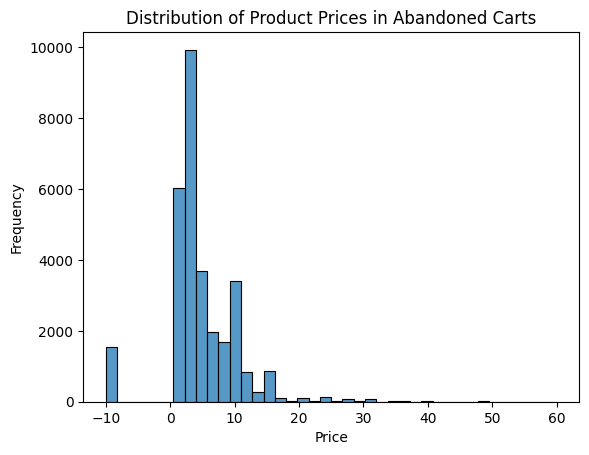

In [69]:
sns.histplot(inv_abandoned["price"], bins=40)
plt.title("Distribution of Product Prices in Abandoned Carts")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

By assigning such a large negative value to the NAN elements, we can easily identify them without distorting our graphs

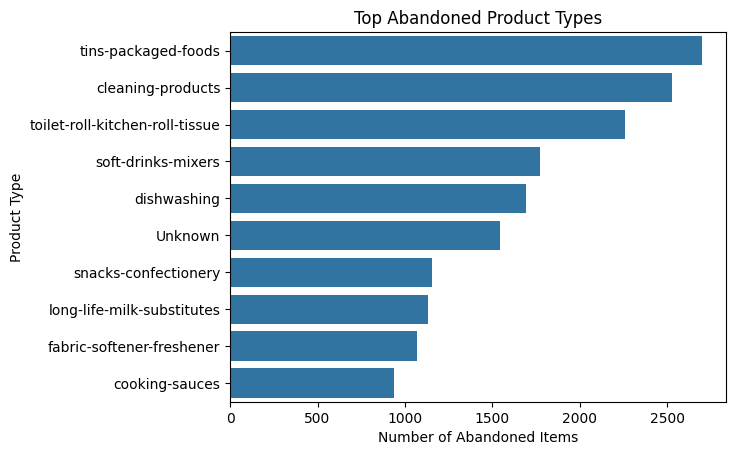

In [71]:
top_types = inv_abandoned["product_type"].value_counts().head(10)

sns.barplot(x=top_types.values, y=top_types.index)
plt.title("Top Abandoned Product Types")
plt.xlabel("Number of Abandoned Items")
plt.ylabel("Product Type")
plt.show()

All missing values are marked as “unknown”; if we could better identify these values and classify them correctly, we might be able to extract relevant information.

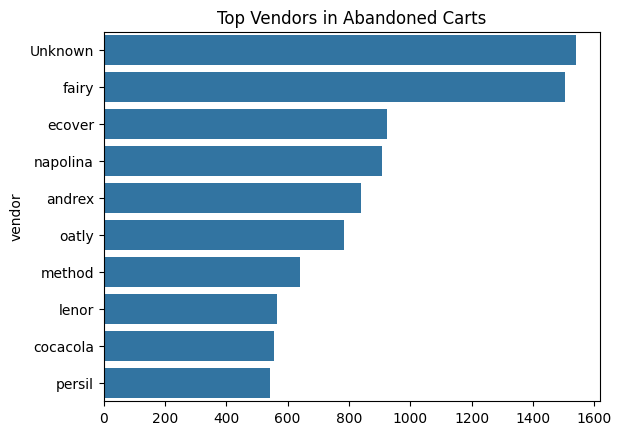

In [72]:
top_vendor = inv_abandoned["vendor"].value_counts().head(10)

sns.barplot(x=top_vendor.values, y=top_vendor.index)
plt.title("Top Vendors in Abandoned Carts")
plt.show()

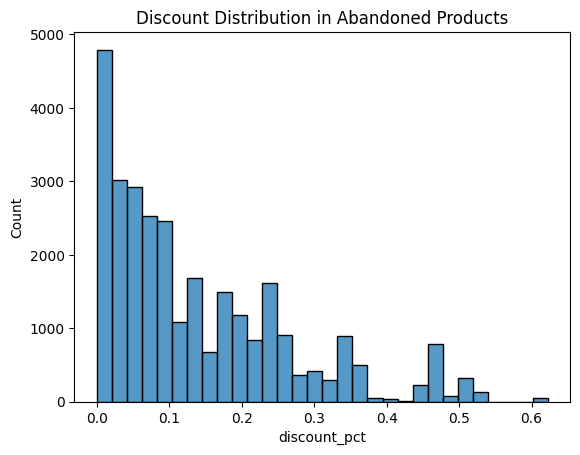

In [74]:
inv_abandoned["discount_pct"] = np.where(
    inv_abandoned["price"] != -10,
    (inv_abandoned["compare_at_price"] - inv_abandoned["price"]) /
    inv_abandoned["compare_at_price"],
    np.nan
)

sns.histplot(inv_abandoned["discount_pct"], bins=30)
plt.title("Discount Distribution in Abandoned Products")
plt.show()

Missing price values were encoded as -10 in the dataset. These values were treated as missing and excluded from discount calculations.

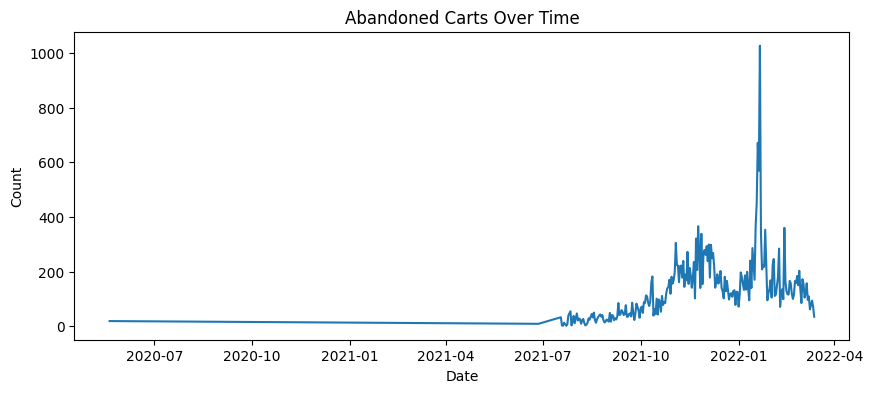

In [76]:
inv_abandoned["created_at"].dt.date.value_counts().sort_index().plot(figsize=(10,4))
plt.title("Abandoned Carts Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

### Insights:

1. The items most often abandoned in shopping carts are the ones with the lowest prices
2. Some products are left on the shelf even when they're on sale
3. The number of abandoned carts remained relatively low and stable until mid-2021, after which a noticeable increase occurs, suggesting higher platform activity or growth in customer traffic.
4. Several sharp spikes in early 2022 indicate periods of unusually high cart abandonment, which could be associated with promotional campaigns, seasonal shopping periods, or increased website traffic.